In [ ]:
!pip install openai pillow --quiet
print(" تم تثبيت المكتبات بنجاح.")

✅ تم تثبيت المكتبات بنجاح.


In [ ]:
import base64
from io import BytesIO
from pathlib import Path
from getpass import getpass

from PIL import Image
from openai import OpenAI
from IPython.display import display

api_key = getpass("Paste your OpenAI API key here: ").strip()
client = OpenAI(api_key=api_key)
print("تم إنشاء عميل OpenAI بنجاح.")

Paste your OpenAI API key here: ··········
✅ تم إنشاء عميل OpenAI بنجاح.


In [ ]:
OUTPUT_DIR = Path("visual_dictionary_images")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_MODEL   = "gpt-image-1"
IMAGE_SIZE    = "1024x1024"
IMAGE_QUALITY = "high"
IMAGE_FORMAT  = "png"


PROMPT_TEMPLATE = """Generate one premium educational image for an Arabic visual dictionary.

Arabic word: {arabic_word}
Definition / meaning: {definition}
Word type: {word_type}
Avoid: {avoid}

Use both the Arabic word and its provided definition to understand the exact intended meaning. The image must visually represent the definition clearly, accurately, and directly.

Create a premium semi-realistic educational dictionary image suitable for a modern Arabic digital lexicon interface. Use one main subject only, neutral white background, high detail, refined composition, soft realistic finish, and natural or studio lighting depending on the subject.

Image rules:
No text, no Arabic letters, no English letters, no numbers, no labels, no captions, no watermark, no logos, no UI elements. Avoid clutter. Use 1:1 square composition. Keep the image culturally appropriate for Arabic and Islamic contexts. No alcohol, no pigs, no inappropriate symbols, no childish cartoon style, no scary hyper-realism.

If the word is an object or tool, show it as a premium studio product image.
If it is an animal, show one semi-realistic animal clearly.
If it is a plant or tree, show the full plant clearly.
If it is food, show it in a clean premium food photography style.
If it is a verb or action, show one modestly dressed person performing the action clearly.
If it is an abstract concept, show a simple symbolic visual metaphor.
If it is a place, show a clear realistic wide-view scene.

Final output: image only."""

print(" تم ضبط الإعدادات وتحميل القالب.")

✅ تم ضبط الإعدادات وتحميل القالب.


In [ ]:
def build_image_prompt(arabic_word, definition, word_type="", avoid=""):
    """يبني prompt إنجليزي ديناميكي من الكلمة ومعناها."""
    return PROMPT_TEMPLATE.format(
        arabic_word=(arabic_word or "").strip(),
        definition=(definition or "").strip(),
        word_type=(word_type or "").strip() or "not specified",
        avoid=(avoid or "").strip() or "nothing specific",
    )

def generate_image(prompt):
    """يرسل الـ prompt إلى gpt-image-1 ويعيد بايتات صورة PNG."""
    response = client.images.generate(
        model=IMAGE_MODEL, prompt=prompt, n=1,
        size=IMAGE_SIZE, quality=IMAGE_QUALITY, output_format=IMAGE_FORMAT,
    )
    b64 = response.data[0].b64_json
    if not b64:
        raise ValueError("لم تُعد الواجهة البرمجية بيانات صورة.")
    return base64.b64decode(b64)

def save_image(image_bytes, arabic_word):
    """يحفظ الصورة في مجلد الحفظ ويعيد المسار."""
    safe = (arabic_word or "word").strip().replace("/", "_").replace("\\", "_") or "word"
    path = OUTPUT_DIR / f"{safe}.png"
    Image.open(BytesIO(image_bytes)).convert("RGB").save(path, format="PNG")
    return path

print(" الدوال جاهزة.")

✅ الدوال جاهزة.


🔤 الكلمة: بَرَادٌ
📝 المعنى: جِهازٌ يُبَرِّدُ الأَطْعِمَةَ والأَشْرِبَةَ ونَحْوَها، ثَلاجَةٌ.
⏳ جاري التوليد بمودل gpt-image-1...
💾 محفوظة: visual_dictionary_images/TEST_تجربة.png



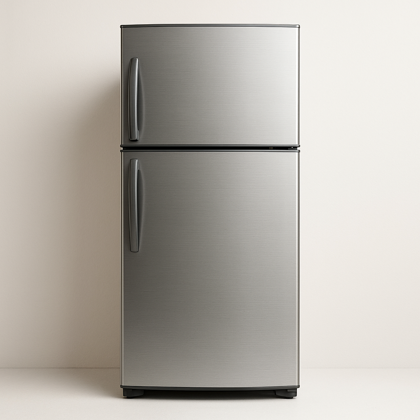

✅ نجحت التجربة. النموذج والقالب يعملان — يمكنك الانتقال للشيت الكامل.


In [ ]:

test_word       = "بَرَادٌ"
test_definition = "جِهازٌ يُبَرِّدُ الأَطْعِمَةَ والأَشْرِبَةَ ونَحْوَها، ثَلاجَةٌ."
test_word_type  = "اسم آلة"
test_avoid      = ""

prompt = build_image_prompt(test_word, test_definition, test_word_type, test_avoid)
print(f" الكلمة: {test_word}\n📝 المعنى: {test_definition}\n⏳ جاري التوليد بمودل {IMAGE_MODEL}...")
try:
    img_bytes = generate_image(prompt)
    test_path = save_image(img_bytes, "TEST_تجربة")
    print(f"💾 محفوظة: {test_path}\n")
    display(Image.open(test_path).resize((420, 420)))
    print(f" نجحت التجربة. النموذج والقالب يعملان — يمكنك الانتقال للشيت الكامل.")
except Exception as e:
    print(f"فشلت التجربة: {e}")

In [ ]:

DICTIONARY_ROWS = [
    {"الكلمة": "بَرَادٌ", "قسم الكلام": "اسم آلة", "التعريف": "جِهازُ يُبَرِّدُ الأَطْعِمَةَ والأَشْرِبَةَ ونَحْوَها ، ثَلاجَةٌ .", "الشاهد": "نَحْفَظُ الطَّعامَ والفاكِهَةَ فِي البَرَادِ كَيْ لَا تَفْسُدَ.\nكانَ تَدْبِيرُ الطَّعامِ والشَّرابِ صَعْبًا قَبْلَ اخْتِراع البَرّاداتِ."},
    {"الكلمة": "بَرَّايَةٌ", "قسم الكلام": "اسم آلة", "التعريف": "آلَةٌ لِبَرْيِ الأَقْلام.", "الشاهد": "عِنْدي بَرّايَةٌ صَغِيرَةٌ أَبْرِي بِها أَقْلامِي.\nأَحْتَفِظُ بِالبَرايَاتِ والأَقلام في مِقْلَمَةٍ اشْتَراها لي أبي."},
]

df = pd.DataFrame(DICTIONARY_ROWS)

for col in ["اسم الصورة", "رابط الصورة", "اسم المودل", "البرومت", "الحالة", "ملاحظات"]:
    if col not in df.columns:
        df[col] = ""
print(f"✅ تم تحميل {len(df)} كلمة.")
df.head()

In [ ]:
from google.colab import files
if last_image_path:
    files.download(str(last_image_path))
else:
    print(" لا توجد صورة لتحميلها — شغّلي خلية التجربة أولًا.")